## Extracting 1D spectroscopy from a 2D spectrum

In this notebook, we'll walk through an example of using basic python tools to extract a 1D spectrum from 2D spectrscopy.  In the first part, we will learn how to do a standard ("boxcar") 1D extraction.  In the second part, we'll learn how to do an "optimized" 1D extraction, which uses the shape of the target galaxy/source to enhance the S/N of the 1D extraction.

In [2]:
import numpy as np # math stuff
import matplotlib.pyplot as plt # plotting stuff
import matplotlib.gridspec as gridspec # plotting with subpanels
from astropy.convolution import Gaussian1DKernel,Gaussian2DKernel # making fake data

# <div class="alert alert-success">
# wdgwgwdd
# </div>  

### Fake data but real methods
Before we start, we're going to need data to work with.  Rather than find an example 2D spectrum from somewhere, for now we're going to make some basic fake data to use instead.  The methodology of how to extract 1D data will be the same, the results just won't be of a real cosmic object. 

> ***Separately, another motivation*** -- Learning how to make fake data is absolutely worth learning.  When you need to test something -- either a new package, a function you haven't used before, a thought experiment you have, etc. -- learning how to quickly make fake data to use is an *incredibly* valuable skill

#### &mdash; What we need
- a 2D array, ideally with one axis much longer (to mimic spectra)
- the spatial trace of a "source", dispersed along the spectral direction
- an emission line, to provide another comparison point
- noise, to simulate how real data looks (i.e., not perfect or pristine!)

In [3]:
# making some fake data
data = np.zeros((100,21)) # rows (spectral direction), columns (spatial direction)
line_spread = Gaussian1DKernel(3.5,x_size=len(data[0])).array # spatial profile
emission_line = Gaussian2DKernel(3.5,3.5,x_size=len(data[0]),y_size=len(data[0])).array # spatial profile

# now let's add it all together into the 2D, column by column
for column in range(len(data)):
    data[column] = line_spread + line_spread * 0.25 * np.random.random(len(line_spread)) # adding randomness, too, for noise!

# adding the emission line in a random place, center of the spatial direction
halfway_column = int(len(data)/2) # index of halfway in x direction
halfway_row = int(len(data[0])/2) # index of halfway in y direction
data[halfway_column-int(emission_line.shape[0]/2):halfway_column+int(emission_line.shape[0]/2)+1,
     halfway_row-int(emission_line.shape[1]/2):halfway_row+int(emission_line.shape[1]/2)+1] += emission_line # adding line

### 0. The basics features of 2D spectroscopy
Very briefly, let's discuss what 2D spectroscopy actually tells us.  Spectroscopy in general relates to how light from &#x2728;something&#x2728; looks along the electromagnetic spectrum &mdash; think of a rainbow, or that Pink Floyd album showing white light entering a triangular prism and a rainbow of light exiting the other side.

I often like to call spectroscopy a light fingerprint, such that everything in the Universe has its own *unique* light fingerprint.  In space, these light fingerprints (spectroscopy) can tell us about the nature of the cosmic objects we study.  Information like what kinds of stars live inside, how abundantly are they forming, is there evidence of an accreting supermassive black hole, how far away is the source, and much more.

When taking spectroscopy using a telescope, that data that come out (after being cleaned & processed by a reduction pipeline) have two dimensions. We call this 2D spectroscopy.  The appearance of this 2D spectroscopy can slightly change depending upon the spectrograph+telescope used as well as the observing strategy employed, but generally 2D spectroscopy can be defined as having two axes of information.  
* The first axis is the **spectral direction**, where you can see the light from the cosmic source spread out as a function of wavelength.
* The second axis is the **spatial direction**, which describes how the light is spread out along the detector for each wavelength step.

For most slitted spectroscopy, the length of the spatial direction corresponds to the length of the metal slit used in the spectrograph.  This is helpful, as it enables you to identify where -- spatially -- your source is located in the 2D spectroscopy, which comes in handy if you happen to have other sources covered by the same slit (so, multiple places of dispersed light in the data).  The diagram below illustrates this.

<p>
  <img width="75%" alt="diagram of how 2D spectroscopy works" src="how-2D-spectroscopy-works.png" style="display: block; margin: 0 auto;">
</p>


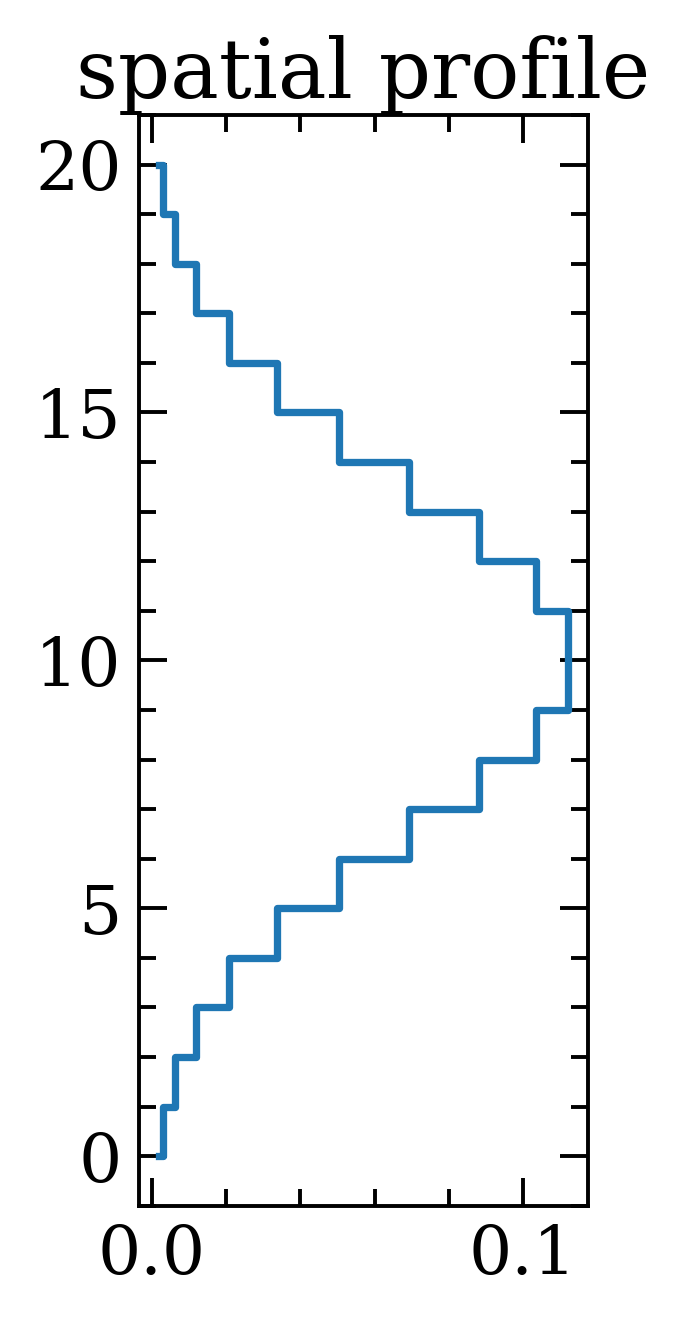

In [3]:
# what the line spread function
plt.figure(figsize=(2,4))
plt.title('spatial profile')
plt.step(line_spread,range(len(data[0])),where='mid')
plt.show()
plt.close()

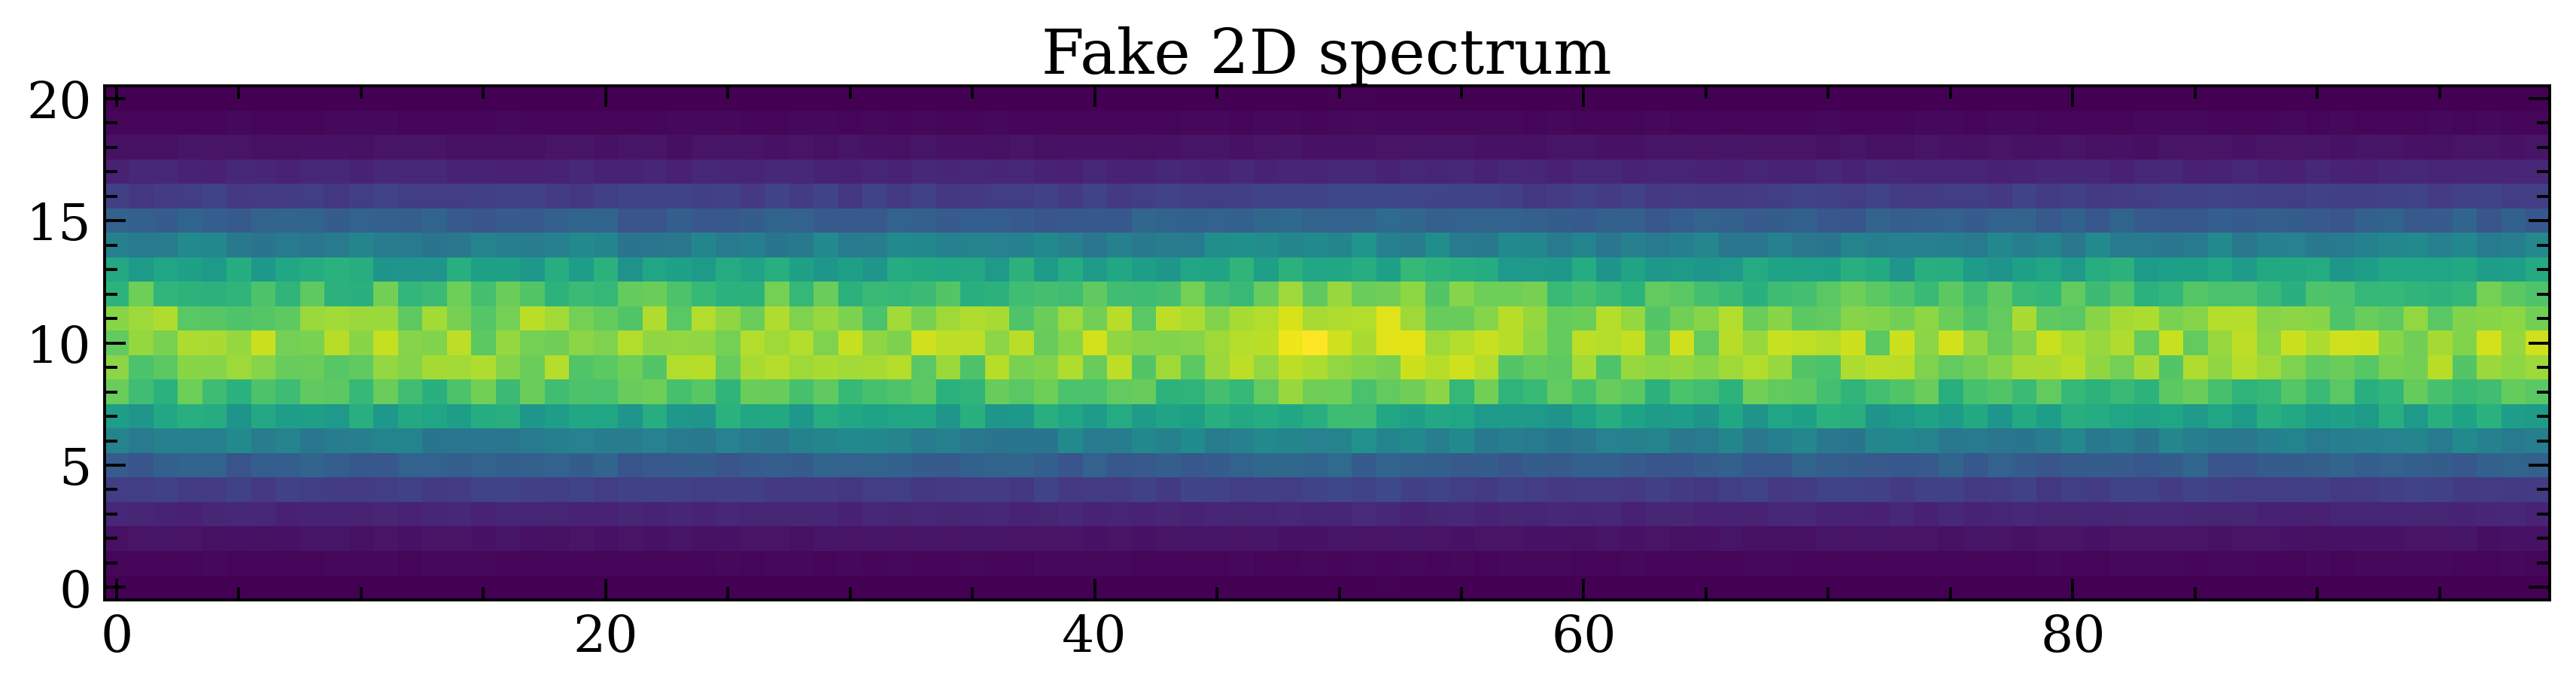

In [4]:
# looking at the fake 2D data
plt.figure(figsize=(10,5))
plt.title('Fake 2D spectrum')
plt.imshow(data.T)
plt.show()
plt.close()

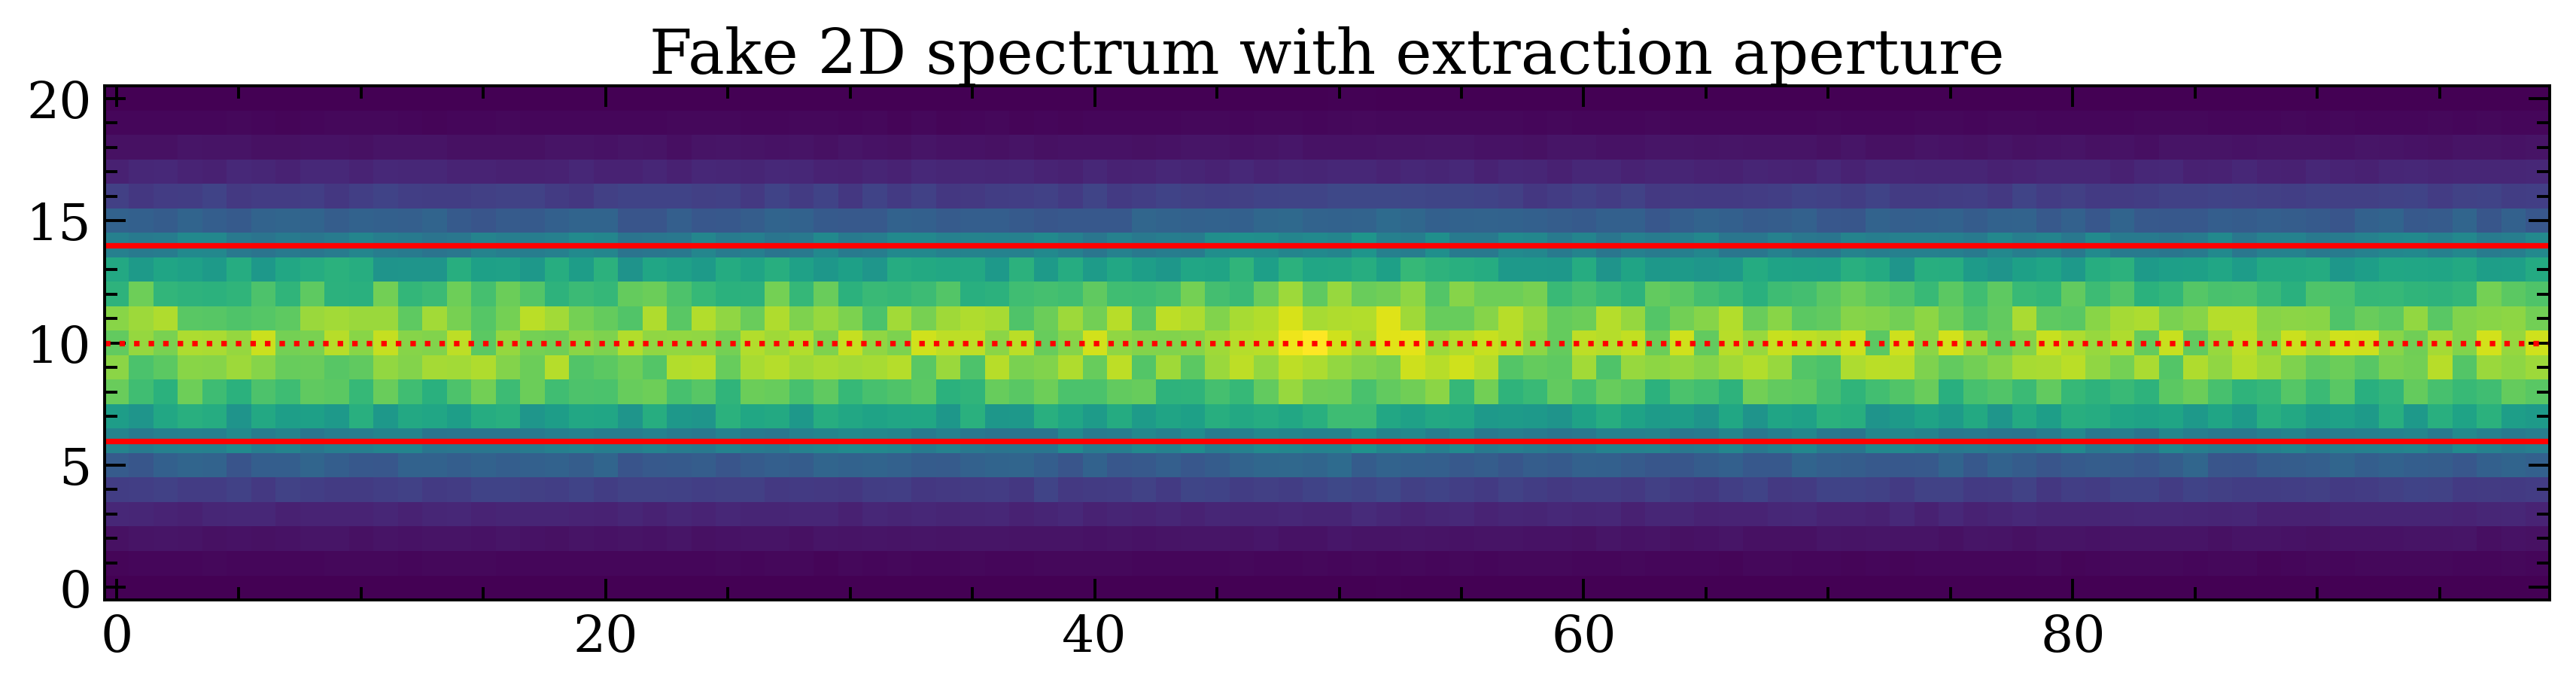

In [5]:
# let's define an aperture for our 1D extraction, too
extraction_width = 9 # needs to be an odd number so it can center on one pixel, with even number of pixels on either side
spatial_center_of_source = 10 # looks like this row?

plt.figure(figsize=(10,5))
plt.title('Fake 2D spectrum with extraction aperture')
plt.imshow(data.T)

# plotting aperture
plt.axhline(spatial_center_of_source,color='r',ls=':') # center of line (shift row number above if not right)
plt.axhline(spatial_center_of_source-int(extraction_width/2),color='r') # upper bound
plt.axhline(spatial_center_of_source+int(extraction_width/2),color='r') # lower bound

plt.show()
plt.close()

In [6]:
arr = np.arange(10)
arr[1:3],arr[[1,2]]

(array([1, 2]), array([1, 2]))

In [7]:
data.shape

(100, 21)

In [8]:
# extracting the spectrum using a boxcar aperture (no weights)
lower_row = spatial_center_of_source - int(extraction_width/2)
upper_row = spatial_center_of_source + int(extraction_width/2)

aperture = [lower_row,upper_row]

boxcar_extraction = np.nansum(data[:,aperture[0]:aperture[1]+1],axis=1)
print('Length of spectrum:',len(boxcar_extraction))

Length of spectrum: 100


In [9]:
# making fake wavelength array
wavelength = np.linspace(3900,6900,len(data))

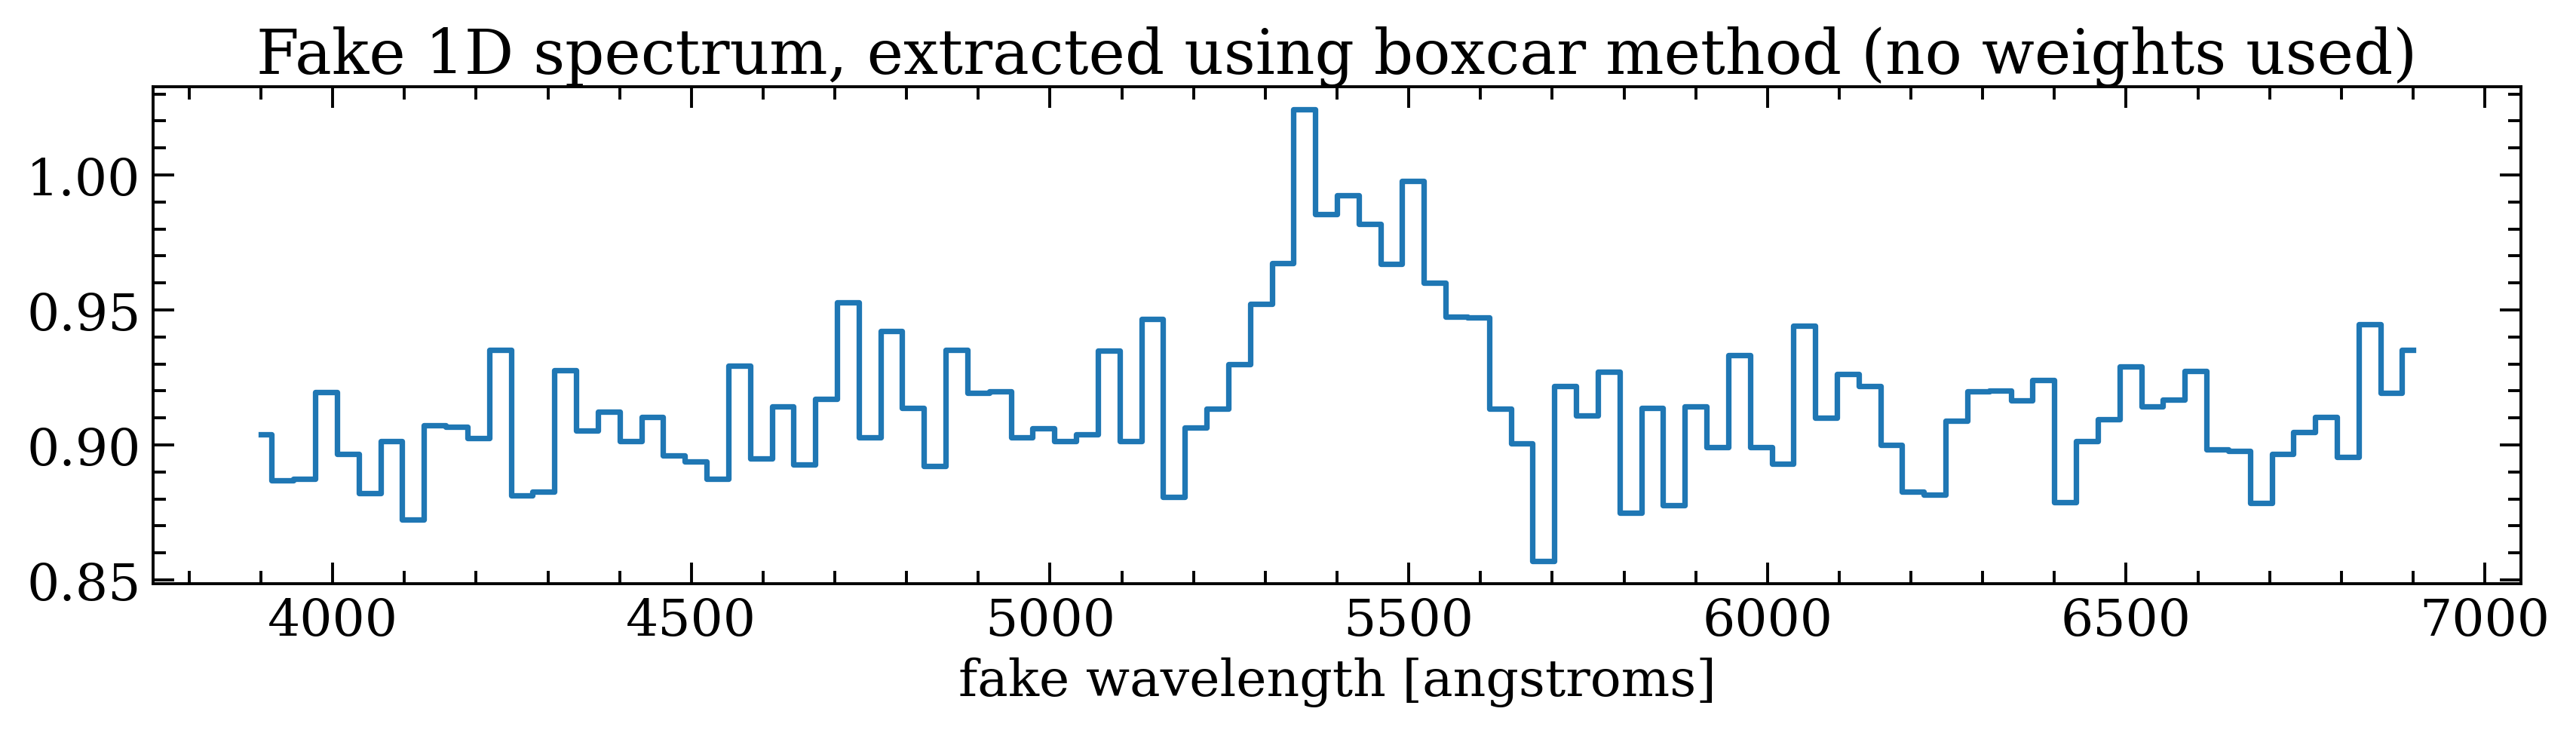

In [10]:
# looking at the boxcar extraction spectrum
plt.figure(figsize=(10,3))
plt.title('Fake 1D spectrum, extracted using boxcar method (no weights used)')

plt.step(wavelength,boxcar_extraction,where='mid')
plt.xlabel('fake wavelength [angstroms]')

plt.show()
plt.close()

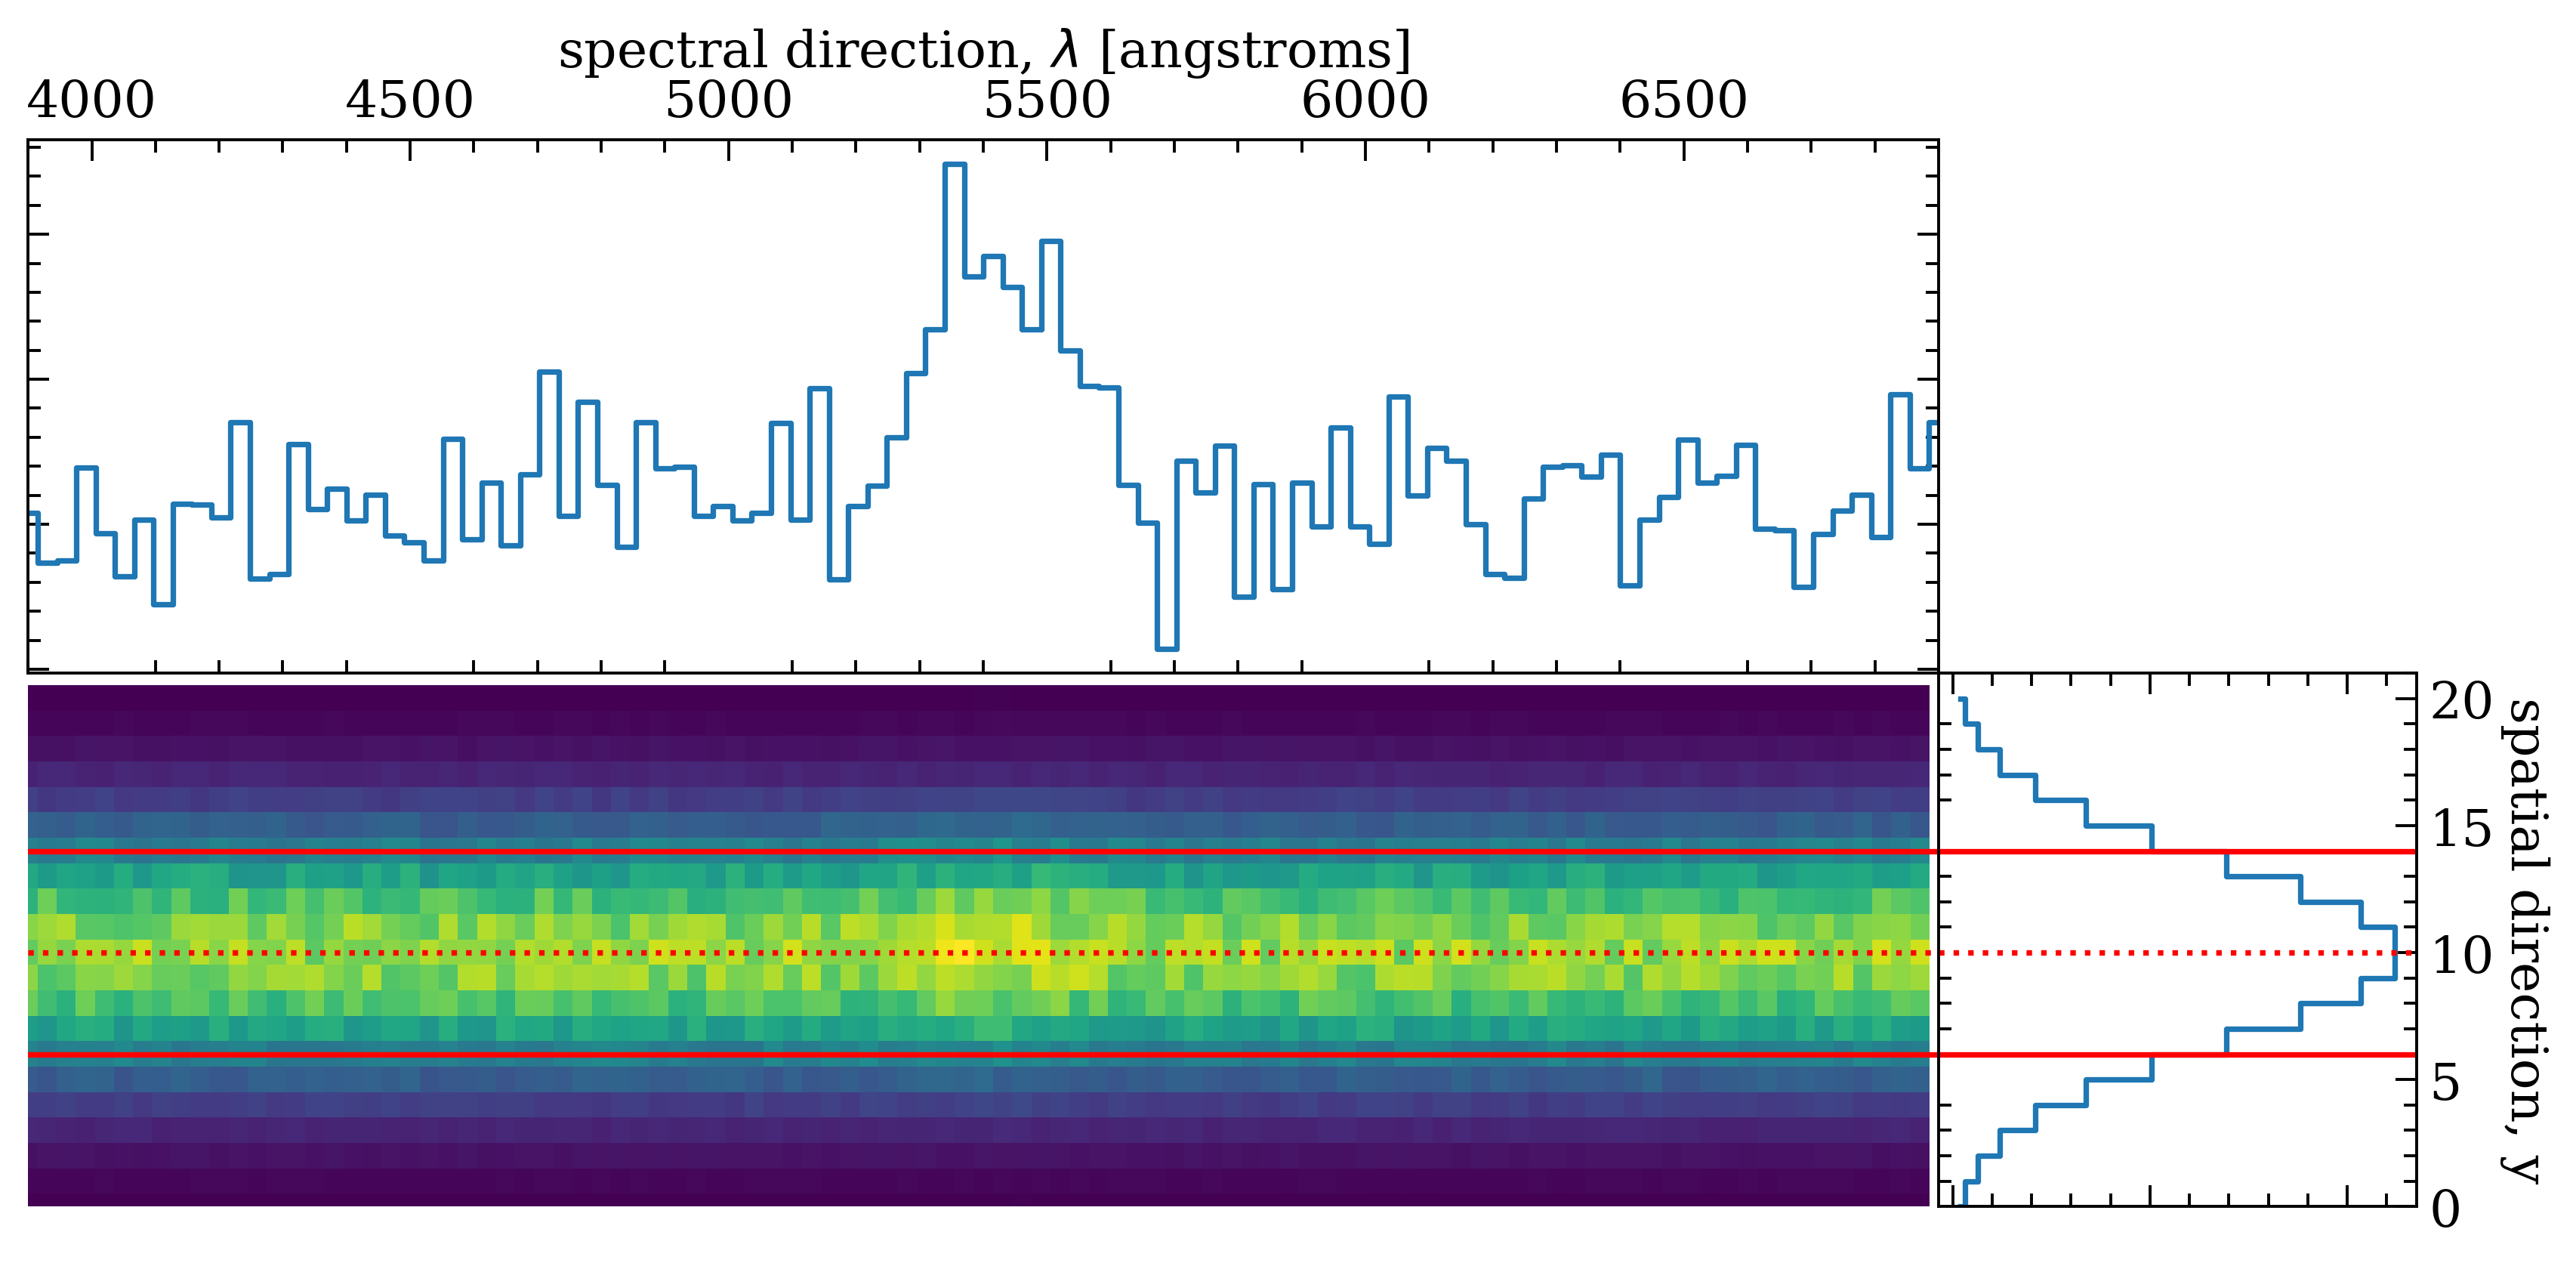

In [11]:
### looking at that together with the 2D, for visualization
plt.figure(figsize=(10,5))
gs = gridspec.GridSpec(2,2,width_ratios=[4,1],height_ratios=[1,1],wspace=0,hspace=0)

# 1D boxcar extraction first
ax_spectrum = plt.subplot(gs[0])
ax_spectrum.step(wavelength,boxcar_extraction,where='mid')
ax_spectrum.set_xlim(wavelength[0],wavelength[-1])
ax_spectrum.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax_spectrum.set_xlabel(r'spectral direction, $\lambda$ [angstroms]')
ax_spectrum.xaxis.set_label_position('top') 
ax_spectrum.set_yticklabels([]) 

# 2D fake spectrum
ax_2D = plt.subplot(gs[2]); ax_2D.axis('off')
ax_2D.imshow(data.T,aspect='auto')
ax_2D.axhline(spatial_center_of_source,color='r',ls=':') # center of line (shift row number above if not right)
ax_2D.axhline(spatial_center_of_source-int(extraction_width/2),color='r') # upper bound
ax_2D.axhline(spatial_center_of_source+int(extraction_width/2),color='r') # lower bound
ax_2D.set_ylim(0,len(line_spread))
ax_2D.set_xlim(0,len(data))

# looking at the 1D spatial profile
ax_spatial1D = plt.subplot(gs[3])
ax_spatial1D.step(line_spread,range(len(data[0])),where='mid')
ax_spatial1D.axhline(spatial_center_of_source,color='r',ls=':') # center of line (shift row number above if not right)
ax_spatial1D.axhline(spatial_center_of_source-int(extraction_width/2),color='r') # upper bound
ax_spatial1D.axhline(spatial_center_of_source+int(extraction_width/2),color='r') # lower bound
ax_spatial1D.set_ylim(0,len(line_spread))
ax_spatial1D.set_xticklabels([]) 
ax_spatial1D.set_ylabel('spatial direction, y',rotation=-90,labelpad=15)
ax_spatial1D.tick_params(right=True, labelright=True, left=False, labelleft=False)
ax_spatial1D.yaxis.set_label_position('right') 

plt.show()
plt.close()


### Optimized Extraction

Originally defined in Horne+1986 [[link](https://articles.adsabs.harvard.edu/pdf/1986PASP...98..609H)], the equation uses the 2D background-subtracted data ($D_{y\lambda}$), the spatial profile (a series of weights to be used in extraction, $P_{y\lambda}$) and the associated 2D variance ($V_{y\lambda}$).  Note that I have replaced $x$ in the original equations with $y$ to better illustrate that it represents the _spatial_ direction, while $\lambda$ represents the _spectral_ direction.


Using these parameters, we can define an optimized extraction from 2D to 1D as:

$$ f^{opt}_\lambda = \frac{\Sigma_y P_{y\lambda} * D_{y\lambda} / V_{y\lambda}}{\Sigma_y P^2_{y\lambda} / V_{y\lambda}} $$

and the associated variance of the optimized extraction equation above is:

$$ var[f^{opt}_\lambda] = \frac{1}{\Sigma_y P^2_{y\lambda} / V_{y\lambda}} $$

In [12]:
# setting up an empty 2D array that we will use to set up our spatial profile weights for each column
profile_2D = np.zeros_like(data)

### reminder of existing variables we will be using:

* `spatial_center_of_source`: center row that the galaxy/spectrum is centered on
* `extraction_width`: the number of rows that will be included in extraction, centered on above variable

When we flesh out our `profile_2D`, we'll only be dealing with rows that we're using for extraction (the rest will remain zero, because we don't need them).

In [13]:
upper_row = spatial_center_of_source + int(extraction_width/2)
lower_row = spatial_center_of_source - int(extraction_width/2)

# setting up our series of weights to be used in the SPATIAL direction
# and because we only care about what's inside the extraction aperture, 
# that's the only part of the line_spread that we'll be copying over
profile_1D = np.zeros_like(line_spread)
profile_1D[lower_row:upper_row+1] = line_spread[lower_row:upper_row+1].copy()

# final step for setting up the weights, we divide the sum of it by 1 so
# that the weights will SUM to 1 (this is critical for our extraction, to not 
# accidentially inflate numbers).
profile_1D /= np.nansum(profile_1D)

# a quick assertion check, will flag if the assert condition is NOT true
assert np.nansum(profile_1D) == 1, 'The weights do not sum to 1!'

### Folding in our 1D spatial profile of weights into the 2D profile array

Essentially we're copying the `profile_1D` into every column of the `profile_2D` array.  Below we'll look at it in 2D and also in 1D (so you can see how this method works in both the spatial and spectral direction!

In [14]:
profile_2D[:] = profile_1D.copy()

# making a basic spectrum extraction for visualization below
profile_spectrum = np.nansum(profile_2D,axis=1)

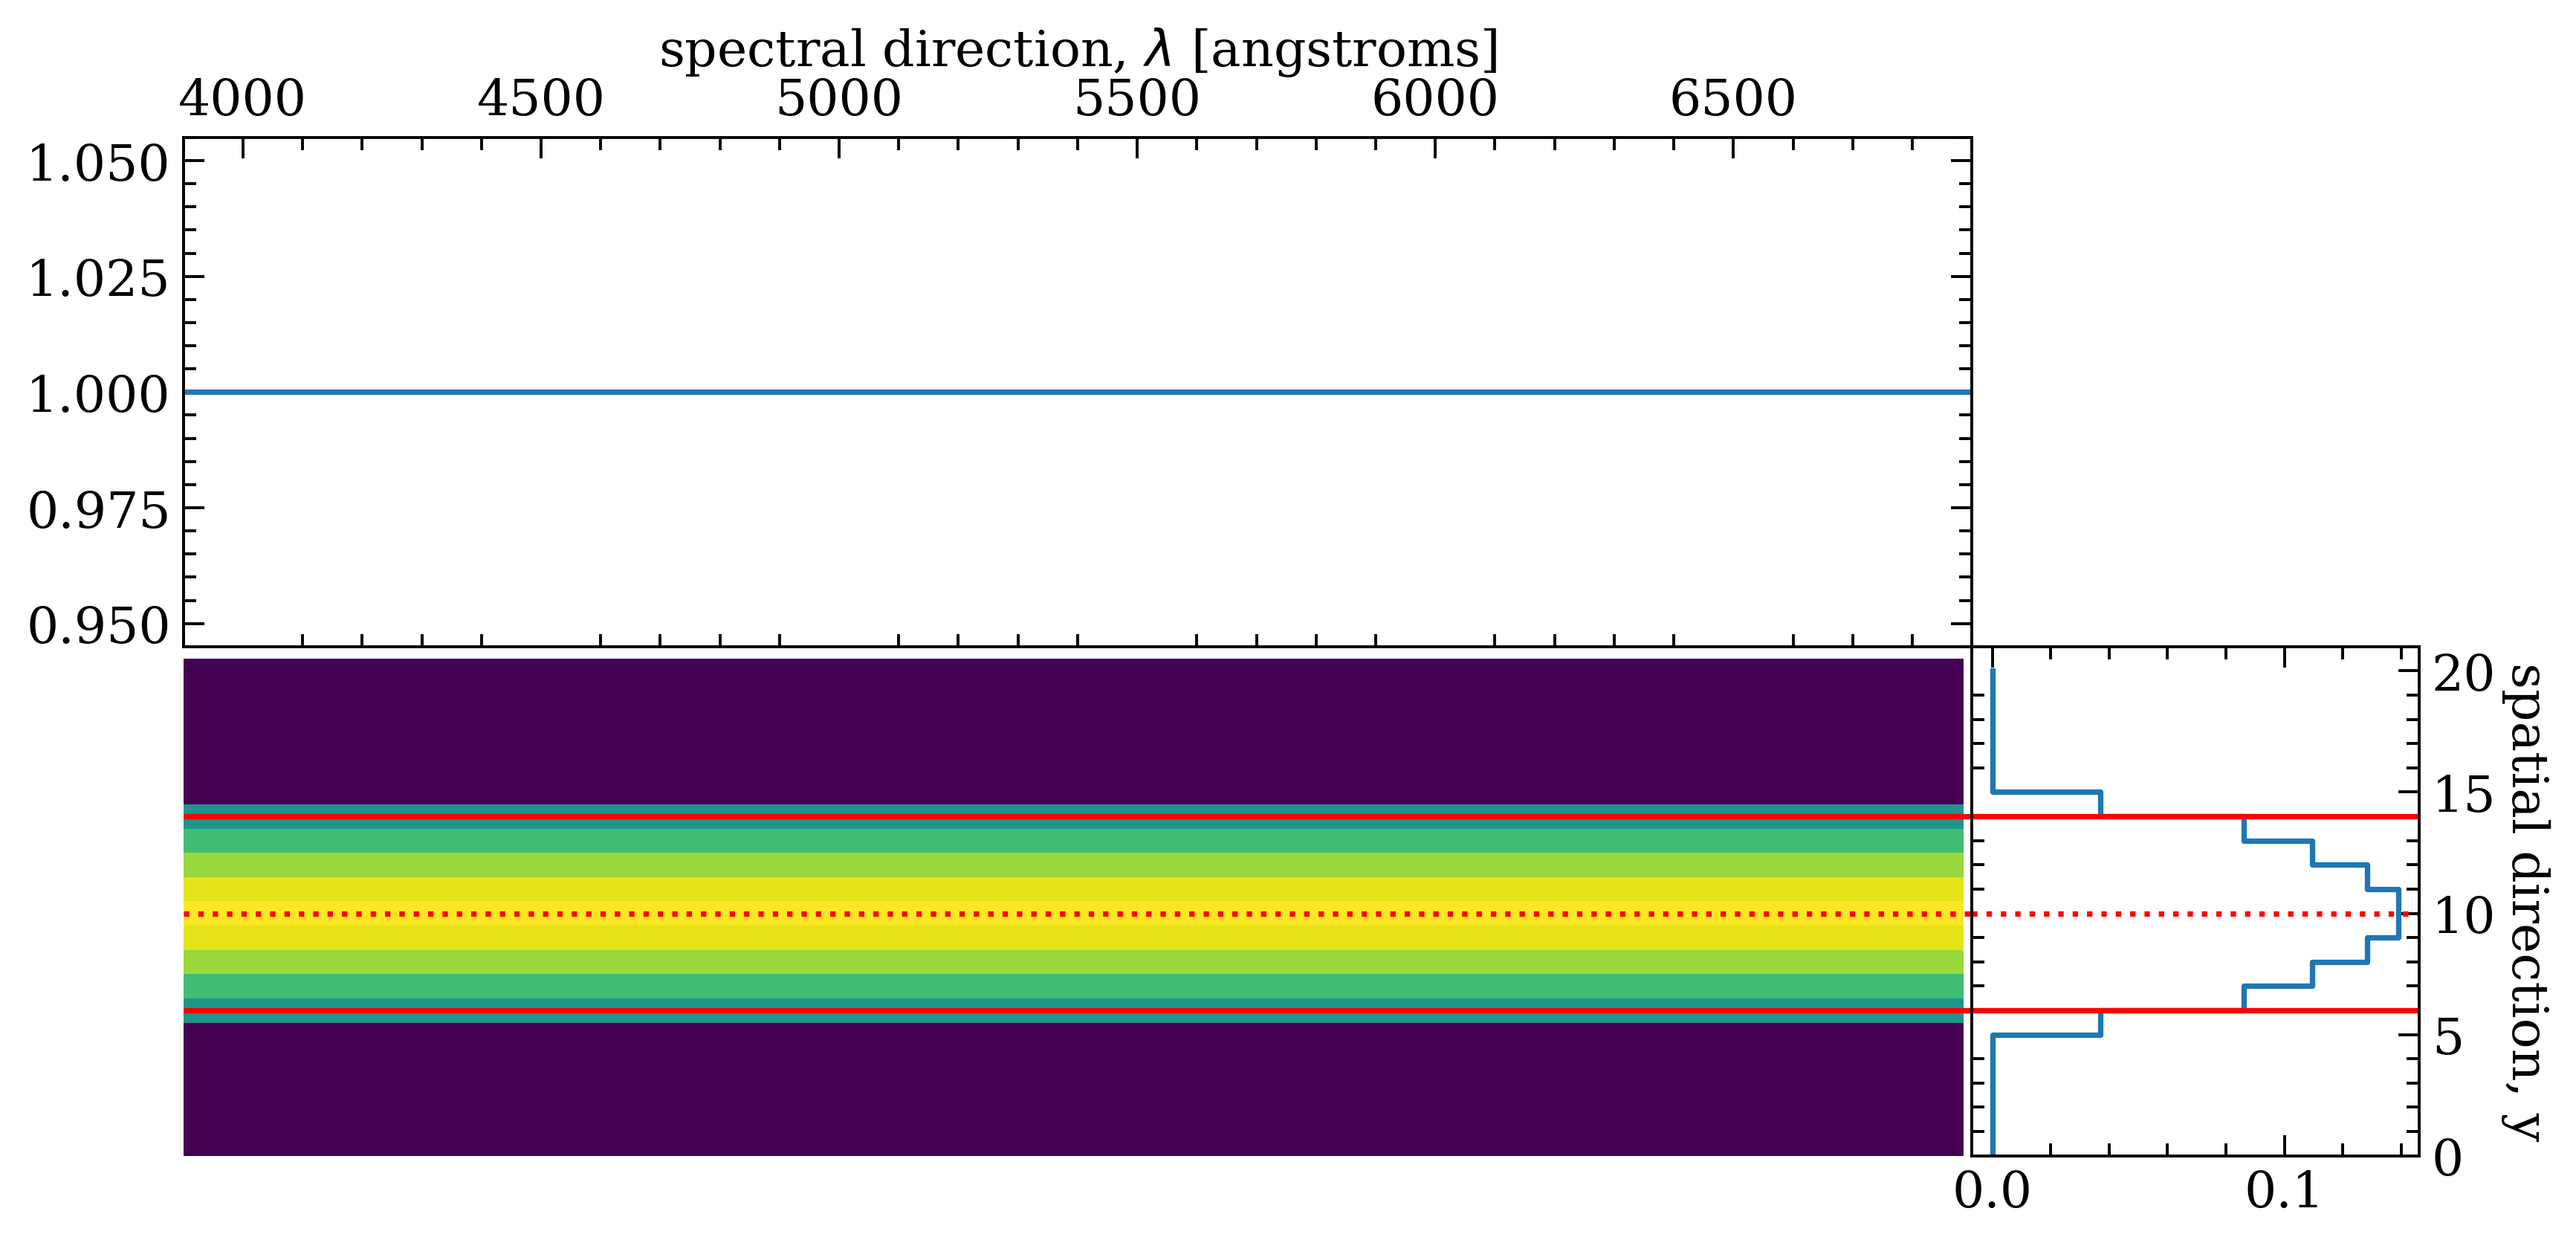

In [15]:
### looking at that together with the 2D, for visualization
plt.figure(figsize=(10,5))
gs = gridspec.GridSpec(2,2,width_ratios=[4,1],height_ratios=[1,1],wspace=0,hspace=0)

# 1D boxcar extraction first
ax_spectrum = plt.subplot(gs[0])
ax_spectrum.step(wavelength,profile_spectrum,where='mid')
ax_spectrum.set_xlim(wavelength[0],wavelength[-1])
ax_spectrum.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax_spectrum.set_xlabel(r'spectral direction, $\lambda$ [angstroms]')
ax_spectrum.xaxis.set_label_position('top') 

# 2D fake spectrum
ax_2D = plt.subplot(gs[2]); ax_2D.axis('off')
ax_2D.imshow(profile_2D.T,aspect='auto')
ax_2D.axhline(spatial_center_of_source,color='r',ls=':') # center of line (shift row number above if not right)
ax_2D.axhline(upper_row,color='r') # upper bound
ax_2D.axhline(lower_row,color='r') # lower bound
ax_2D.set_ylim(0,len(profile_1D))
ax_2D.set_xlim(0,len(profile_2D))

# looking at the 1D spatial profile
ax_spatial1D = plt.subplot(gs[3])
ax_spatial1D.step(profile_1D,range(len(data[0])),where='mid')
ax_spatial1D.axhline(spatial_center_of_source,color='r',ls=':') # center of line (shift row number above if not right)
ax_spatial1D.axhline(upper_row,color='r') # upper bound
ax_spatial1D.axhline(lower_row,color='r') # lower bound
ax_spatial1D.set_ylim(0,len(profile_1D))
# ax_spatial1D.set_xticklabels([]) 
ax_spatial1D.set_ylabel('spatial direction, y',rotation=-90,labelpad=15)
ax_spatial1D.tick_params(right=True, labelright=True, left=False, labelleft=False)
ax_spatial1D.yaxis.set_label_position('right') 

plt.show()
plt.close()


Note that the "extracted" 1D spectrum is all equal to 1, for each wavelength step.  This is good, because that means every column (the spatial direction) is summing to 1 -- as it should, because this 2D array will be our weights!

### Now, prepping the rest of what we need

Really quickly, let's make a fake 2D uncertainty array (because with real data you have both the signal and the error given to you).

In [16]:
# random numbers between 0 and 1, in the 2D shape like data, multiplied by 0.1 to make small
error = np.zeros_like(data)
error[:] = 0.3 * line_spread
error += 0.01 * np.random.random(data.shape)
error.shape

(100, 21)

/Users/tahutch1/miniforge3/envs/stenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


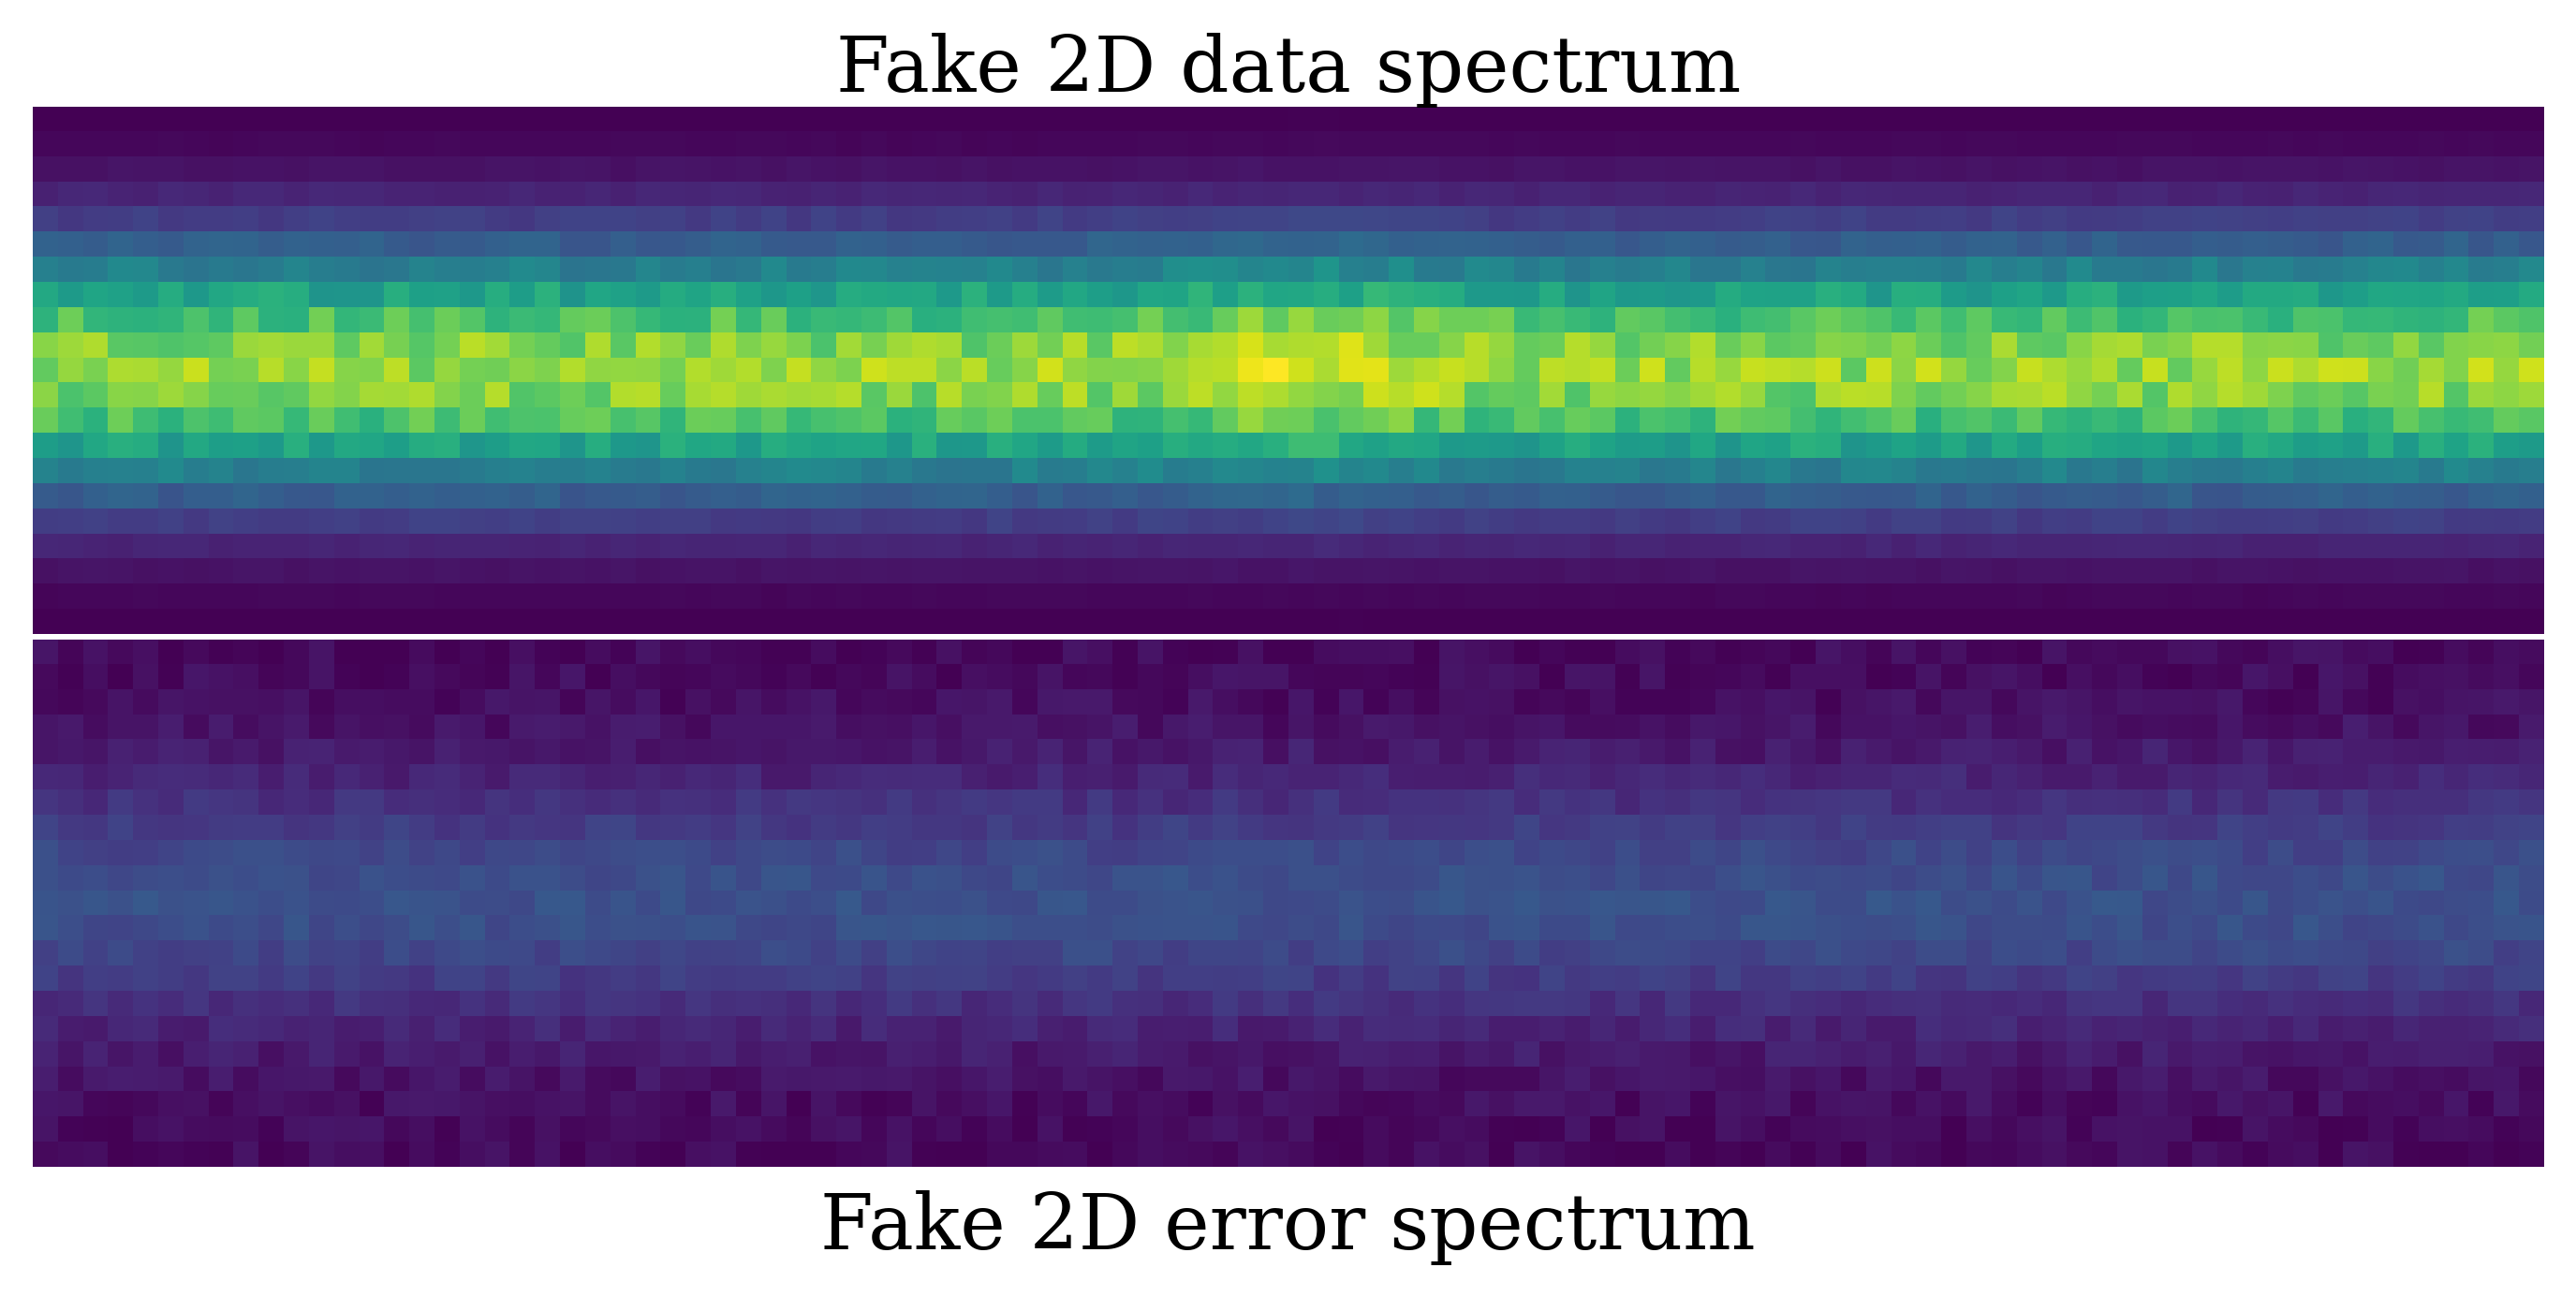

In [18]:
# looking at the fake 2D error with the fake 2D data
plt.figure(figsize=(10,4.2))
gs = gridspec.GridSpec(2,1,height_ratios=[1,1],hspace=0.01)

ax_data = plt.subplot(gs[0])
ax_data.axis('off') # don't need the x and y labels
ax_data.set_title('Fake 2D data spectrum')
im = ax_data.imshow(data.T)
clims = im.get_clim() # to match both panels' colorbars

ax_error = plt.subplot(gs[1])
ax_error.axis('off') # don't need the x and y labels
ax_error.set_title('Fake 2D error spectrum',y=-0.18)
ax_error.imshow(error.T,clim=clims)

plt.show()
plt.close()

## We're ready to do an optimized extraction.
The code may flag a "divide by zero" error, but that's okay it's for the regions of the 2D spectrum that we don't care about (outside of the extraction aperture we defined above).

In [19]:
# setting up numerator and denominator separately, as they need to sum separately
optimized_numerator_2D = ( profile_2D * data / error ) 
optimized_denominator_2D = ( profile_2D**2 / error )

# collapsing spatially to make the final 1D spectrum
optimized_numerator_extraction = np.nansum(optimized_numerator_2D[:,lower_row:upper_row+1],axis=1)
optimized_denominator_extraction = np.nansum(optimized_denominator_2D[:,lower_row:upper_row+1],axis=1)
optimized_extraction = optimized_numerator_extraction / optimized_denominator_extraction

# optimized_extraction = np.nansum(optimized_2D[:,lower_row:upper_row+1],axis=1)
optimized_extraction.shape

(100,)

Now we calculate the optimized error.

In [20]:
optimized_error_2D = 1 / ( profile_2D**2 / error )

# collapsing spatially to make the final 1D error spectrum
optimized_extraction_error = np.nansum(optimized_error_2D[:,lower_row:upper_row],axis=1)
optimized_extraction_error.shape

/var/folders/bd/fxffskzs3rvczrn0b8m7jpn46n113h/T/ipykernel_76850/2987205768.py:1: RuntimeWarning: divide by zero encountered in divide
  optimized_error_2D = 1 / ( profile_2D**2 / error )


(100,)

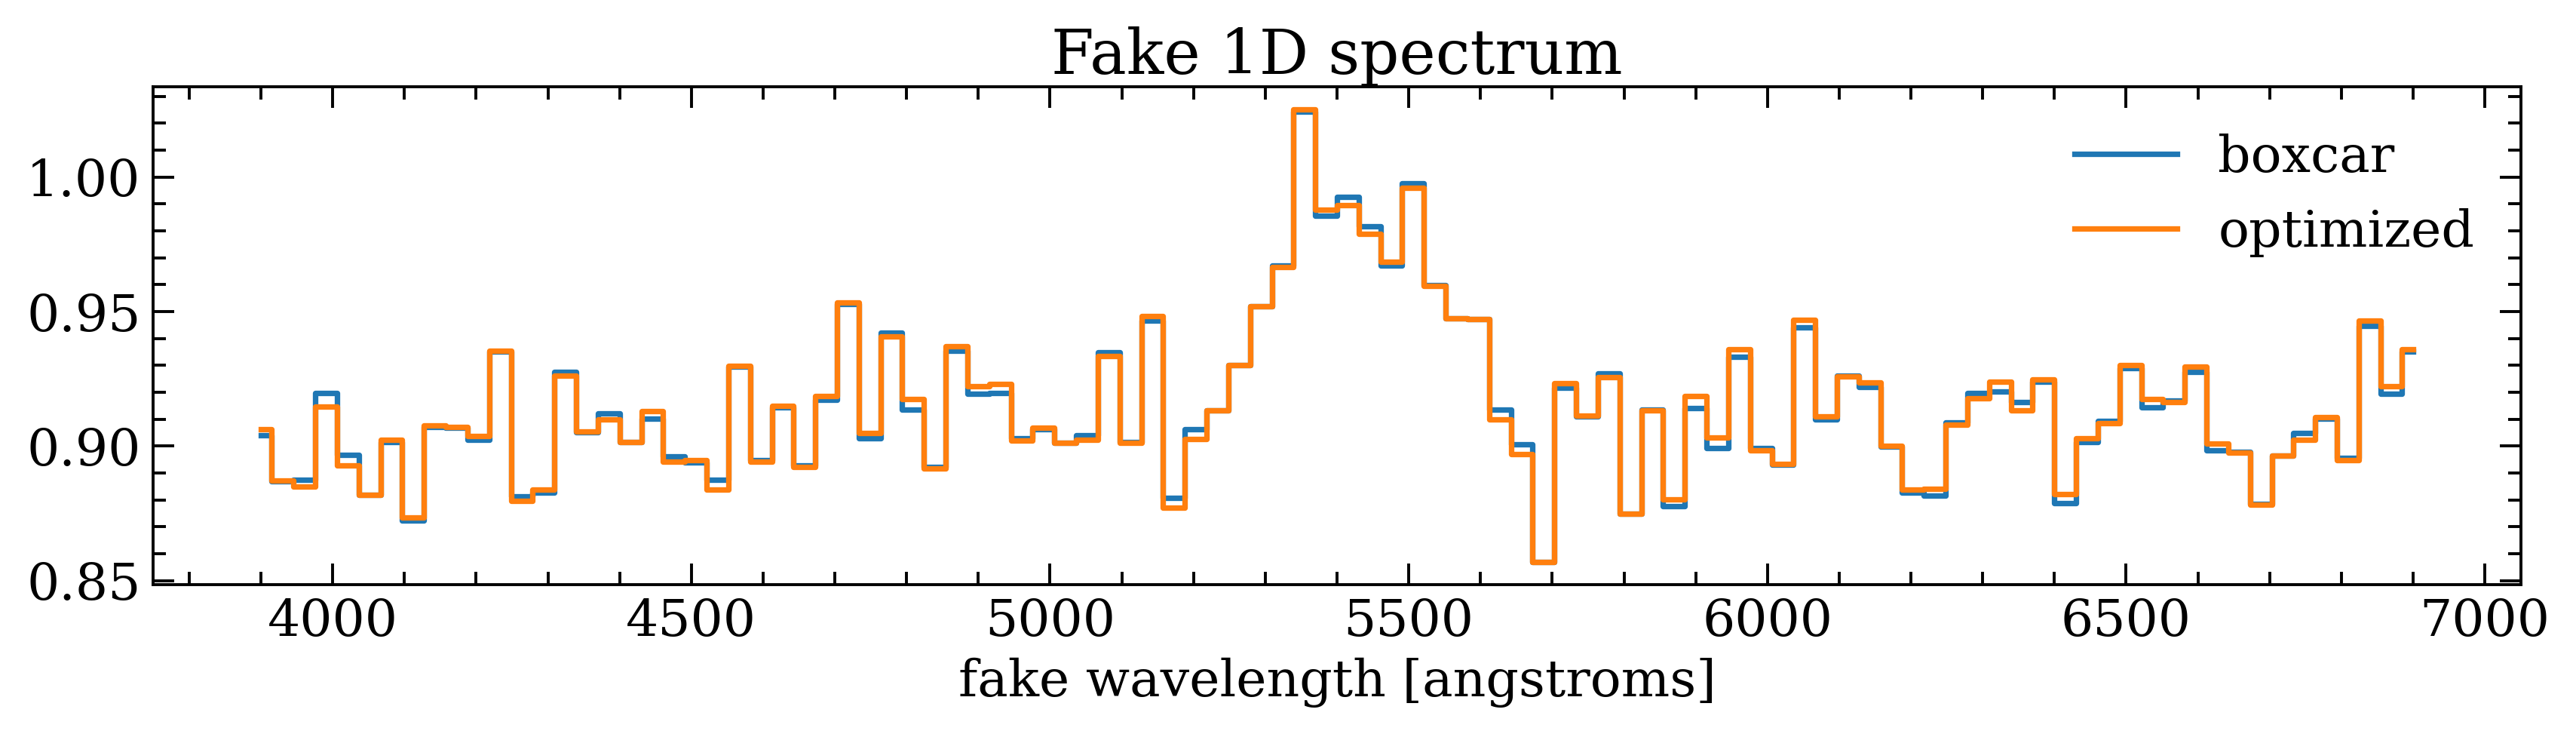

In [21]:
# looking at the boxcar extraction spectrum
plt.figure(figsize=(10,3))
plt.title('Fake 1D spectrum')

plt.step(wavelength,boxcar_extraction,where='mid',label='boxcar')
plt.step(wavelength,optimized_extraction,where='mid',label='optimized')

plt.xlabel('fake wavelength [angstroms]')
plt.legend()

plt.show()
plt.close()

In this case, we don't see that much of a difference -- but that's because this is fake data made to look pretty bright (so minimal changes for brighter things).

BUT this methodology is perfect for fainter things and can be used for all types & exposure times of data.